In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
Maria_data = ('~/Desktop/ISAT-Semester-Project/Hurricane Maria/table1_best_track.csv')
ds = pd.read_csv(Maria_data, na_values = [-999, -9999], )

In [26]:
ds

,Date/Time (UTC),Latitude (°N),Longitude (°W),Pressure (mb),Wind Speed (kt),Stage,Notes
0,16/1200,12.2,49.7,1006.0,30.0,tropical depression,NaN
1,16/1800,12.2,51.7,1004.0,40.0,tropical storm,NaN
2,17/0000,12.4,53.1,1002.0,45.0,tropical storm,NaN
3,17/0600,12.8,54.4,994.0,55.0,tropical storm,NaN
4,17/1200,13.3,55.7,990.0,60.0,tropical storm,NaN
...,...,...,...,...,...,...,...
64,01/1800,46.5,31.0,1003.0,45.0,extratropical,NaN
65,02/0000,47.5,26.5,1005.0,40.0,extratropical,NaN
66,02/0600,48.0,22.0,1012.0,40.0,extratropical,NaN
67,02/1200,48.0,17.0,1016.0,30.0,extratropical,NaN


In [27]:
columns_to_keep = ['Date/Time (UTC)','Wind Speed (kt)']
ds = ds[columns_to_keep]
ds

,Date/Time (UTC),Wind Speed (kt)
0,16/1200,30.0
1,16/1800,40.0
2,17/0000,45.0
3,17/0600,55.0
4,17/1200,60.0
...,...,...
64,01/1800,45.0
65,02/0000,40.0
66,02/0600,40.0
67,02/1200,30.0


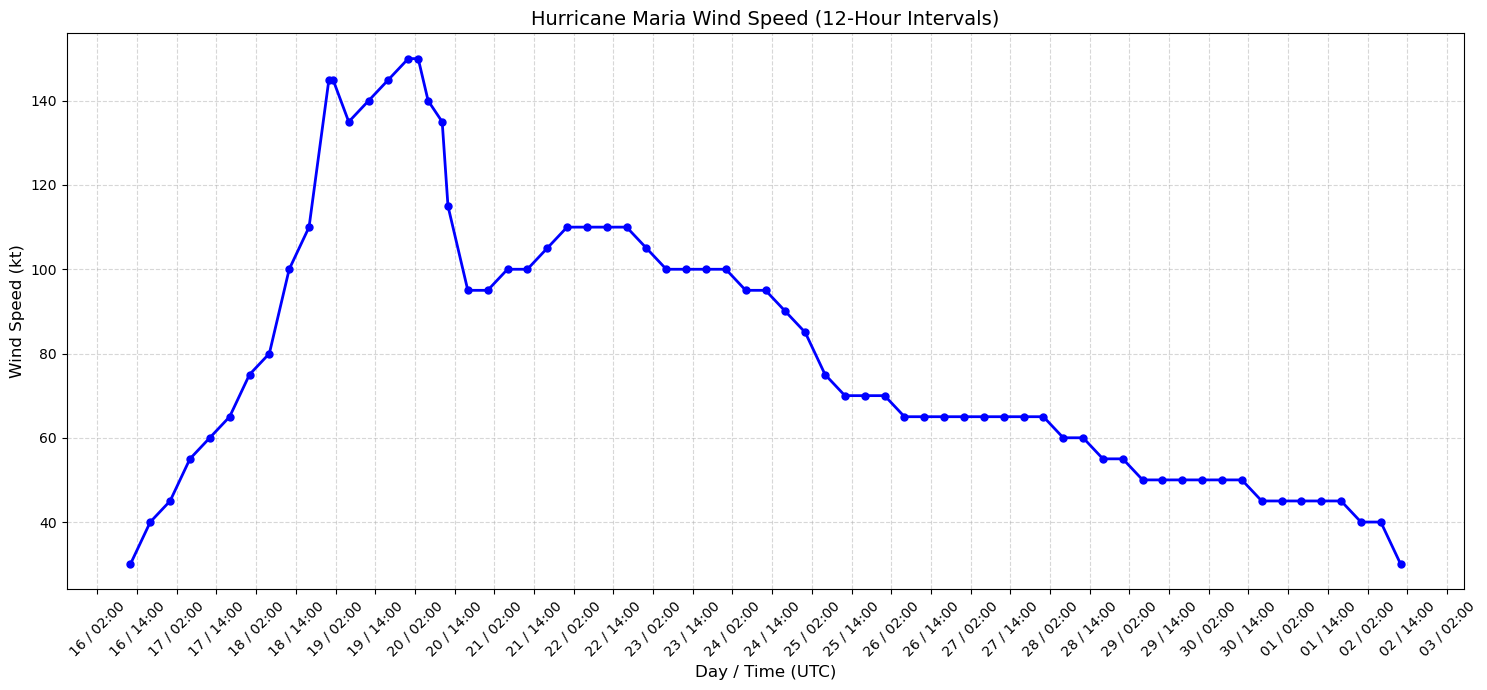

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Resetting/Cleaning (just in case)
ds = pd.read_csv(Maria_data, na_values=[-999, -9999])
ds.columns = ds.columns.str.strip()
ds = ds.dropna(subset=['Wind Speed (kt)'])

# 2. Fix the dates to 2017 so the timeline is continuous
def fix_hurricane_date(row):
    day = int(row.split('/')[0])
    month = 9 if day >= 16 else 10
    return pd.to_datetime(f"2017-{month}-{row}", format="%Y-%m-%d/%H%M")

ds['Date/Time (UTC)'] = ds['Date/Time (UTC)'].apply(fix_hurricane_date)

# 3. Plot
plt.figure(figsize=(15, 7))
plt.plot(ds['Date/Time (UTC)'], ds['Wind Speed (kt)'], marker='o', markersize=5, color='blue', linewidth=2)

# 4. THE FIX: Set 12-hour intervals and show ONLY Day and Time
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=12))

# Format: %d is Day, %H:%M is Time. (Removed %b which was the Month)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d / %H:%M'))

# 5. Styling and Labels
plt.title('Hurricane Maria Wind Speed (12-Hour Intervals)', fontsize=14)
plt.xlabel('Day / Time (UTC)', fontsize=12) # Updated to match your request
plt.ylabel('Wind Speed (kt)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45) 
plt.tight_layout()

plt.show()

In [37]:
# Save the plot as a high-resolution PNG
plt.savefig('hurricane_maria_wind_speed.png', dpi=300, bbox_inches='tight')

# Keep this at the very end
plt.show()

<Figure size 640x480 with 0 Axes>